In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
print("Number of train images:", len(train_dataset))
print("Number of test images:", len(test_dataset))

Number of training images: 60000
Number of test images: 10000


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Defining the Neural Network

The network consists of one hidden layer with ReLU activation followed by an output layer containing 10 neurons, one for each class.

In [12]:
class DigitClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 96)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(96, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

net = DigitClassifier().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    net.parameters(),
    lr=0.001
)

In [14]:
print(device)

cpu


Training

In [15]:
epochs = 10
loss_values = []

for epoch in range(epochs):
    net.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/10 | Loss: 0.2793
Epoch 2/10 | Loss: 0.1251
Epoch 3/10 | Loss: 0.0903
Epoch 4/10 | Loss: 0.0697
Epoch 5/10 | Loss: 0.0574
Epoch 6/10 | Loss: 0.0484
Epoch 7/10 | Loss: 0.0383
Epoch 8/10 | Loss: 0.0322
Epoch 9/10 | Loss: 0.0299
Epoch 10/10 | Loss: 0.0238


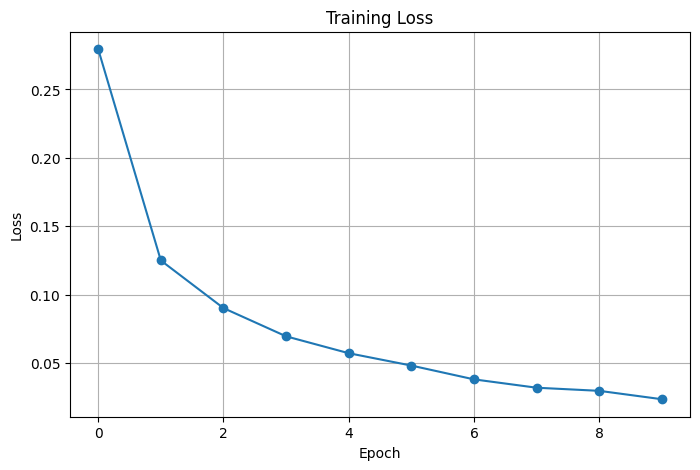

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_values, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [17]:
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Final Test Accuracy: {100 * correct / total:.2f}%")

Final Test Accuracy: 97.78%


Backpropagation is the method used by the neural network to improve its predictions. After making a prediction, the model checks how far it is from the correct answer and calculates the error. This error is passed backwards through the network and the weights are updated acordingly. Over many iterations, these updates help reduce the error and improve the overal accuracy of the model. In simple words, it helps the model learn from its mistakes and make better predictions next time.